In [ ]:
!pip install -q pesq pystoi

import os
import random
import zipfile
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import math
from pesq import pesq
from pystoi import stoi
from google.colab import drive

# 1. 구글 드라이브 마운트
drive.mount('/content/drive', force_remount=True)

# 2. 경로 설정
DATA_DIR = '/content/drive/MyDrive/UNet'
COMPARATION_DIR = '/content/drive/MyDrive/UNet_GAN_Upgraded/Comparation'
RESULT_DIR = f'{COMPARATION_DIR}/Comparison_Results'

if not os.path.exists(RESULT_DIR):
    os.makedirs(RESULT_DIR)

VOICE_ZIP = f'{DATA_DIR}/Korean_Voice/KsponSpeech_01.zip'
NOISE_ZIP = f'{DATA_DIR}/Clean_Noise_Zips/Cleaned_Noise_All.zip'

# 3. 모델 구조 정의 (기존 구조와 업그레이드 구조 모두 필요)

# [A] 기존 U-Net 구조 (unet_only, unet_gan 용)
class UNetMasker(nn.Module):
    def __init__(self):
        super(UNetMasker, self).__init__()
        self.enc1 = nn.Conv2d(1, 32, 3, padding=1)
        self.enc2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec2 = nn.Conv2d(64, 32, 3, padding=1)
        self.dec1 = nn.Conv2d(32, 1, 3, padding=1)

    def forward(self, x):
        e1 = F.relu(self.enc1(x))
        e2 = F.relu(self.enc2(self.pool(e1)))
        d2 = F.relu(self.dec2(self.up(e2)))
        if d2.size() != e1.size(): d2 = F.interpolate(d2, size=e1.shape[2:])
        mask = torch.sigmoid(self.dec1(d2))
        return x * mask, mask

# [B] 업그레이드 U-Net 구조 (upgraded_gan 용)
class ResBlock(nn.Module):
    def __init__(self, channels):
        super(ResBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels)
        )
    def forward(self, x):
        return F.leaky_relu(x + self.conv(x), 0.2)

class UpgradedUNet(nn.Module):
    def __init__(self):
        super(UpgradedUNet, self).__init__()
        self.enc1 = nn.Sequential(nn.Conv2d(1, 64, 3, padding=1), nn.LeakyReLU(0.2))
        self.res1 = ResBlock(64)
        self.down1 = nn.Conv2d(64, 128, 4, stride=2, padding=1)
        self.res2 = ResBlock(128)
        self.down2 = nn.Conv2d(128, 256, 4, stride=2, padding=1)
        self.res3 = ResBlock(256)
        self.up2 = nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1)
        self.dec2 = nn.Sequential(nn.Conv2d(256, 128, 3, padding=1), ResBlock(128))
        self.up1 = nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1)
        self.dec1 = nn.Sequential(nn.Conv2d(128, 64, 3, padding=1), ResBlock(64))
        self.final = nn.Conv2d(64, 1, 3, padding=1)

    def forward(self, x):
        e1 = self.res1(self.enc1(x))
        e2 = self.res2(F.leaky_relu(self.down1(e1), 0.2))
        e3 = self.res3(F.leaky_relu(self.down2(e2), 0.2))
        d2 = self.up2(e3)
        if d2.size() != e2.size(): d2 = F.interpolate(d2, size=e2.shape[2:])
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        if d1.size() != e1.size(): d1 = F.interpolate(d1, size=e1.shape[2:])
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        mask = torch.sigmoid(self.final(d1))
        return x * mask, mask

# 4. 헬퍼 함수 정의
def get_spec(audio):
    window = torch.hann_window(512).to(audio.device)
    spec = torch.stft(audio.squeeze(1), n_fft=512, hop_length=160, window=window, return_complex=True, center=True)
    return torch.abs(spec), torch.angle(spec)

def spec_to_wav(mag, phase):
    complex_spec = torch.polar(mag, phase)
    return torch.istft(complex_spec, n_fft=512, hop_length=160, center=True)

def get_random_test_samples(voice_zip, noise_zip, temp_dir='/content/temp_test'):
    if not os.path.exists(temp_dir): os.makedirs(temp_dir)
    with zipfile.ZipFile(voice_zip, 'r') as z:
        min_bytes = 16000 * 2 * 4
        valid_infos = [info for info in z.infolist() if info.filename.endswith('.pcm') and info.file_size >= min_bytes]
        target_info = random.choice(valid_infos)
        z.extract(target_info, temp_dir)
        voice_path = os.path.join(temp_dir, target_info.filename)

    with zipfile.ZipFile(noise_zip, 'r') as z:
        wav_files = [f for f in z.namelist() if f.endswith('.wav')]
        target_wav = random.choice(wav_files)
        z.extract(target_wav, temp_dir)
        noise_path = os.path.join(temp_dir, target_wav)
    return voice_path, noise_path

def calculate_metrics(clean_wav, denoised_wav, sr=16000):
    min_len = min(len(clean_wav), len(denoised_wav))
    clean_wav = clean_wav[:min_len]
    denoised_wav = denoised_wav[:min_len]

    try:
        pesq_score = pesq(sr, clean_wav, denoised_wav, 'wb')
    except:
        pesq_score = 0.0

    stoi_score = stoi(clean_wav, denoised_wav, sr, extended=False)

    noise = clean_wav - denoised_wav
    signal_power = np.sum(clean_wav ** 2)
    noise_power = np.sum(noise ** 2)
    snr_score = 10 * math.log10(signal_power / (noise_power + 1e-9))

    return pesq_score, stoi_score, snr_score

def load_checkpoint(model, path, device):
    checkpoint = torch.load(path, map_location=device)
    if 'generator_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['generator_state_dict'])
    elif 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
    model.eval()
    return model

# 5. 모델 로드 준비
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_info = {
    'UNet_Only': {'path': f'{COMPARATION_DIR}/unet_only_model.pth', 'class': UNetMasker},
    'UNet_GAN': {'path': f'{COMPARATION_DIR}/unet_gan_model.pth', 'class': UNetMasker},
    'Upgraded_GAN': {'path': f'{COMPARATION_DIR}/upgraded_gan_model.pth', 'class': UpgradedUNet}
}

models = {}
for name, info in model_info.items():
    if os.path.exists(info['path']):
        print(f"✅ 모델 로드 중: {name} ({os.path.basename(info['path'])})")
        m = info['class']().to(device)
        models[name] = load_checkpoint(m, info['path'], device)
    else:
        print(f"❌ 오류: {info['path']} 파일이 없습니다.")

# 성능 기록을 위한 딕셔너리
metrics_history = {name: {'PESQ': [], 'STOI': [], 'SNR': []} for name in models.keys()}

# 6. 검증 실행 (10회 반복)
for i in range(10):
    print(f"\n--- 테스트 샘플 {i+1}/10 진행 중 ---")
    v_path, n_path = get_random_test_samples(VOICE_ZIP, NOISE_ZIP)

    with open(v_path, 'rb') as f:
        clean = np.frombuffer(f.read(), dtype=np.int16).astype(np.float32) / 32768.0

    try:
        noise, _ = librosa.load(n_path, sr=16000, duration=6.0)
    except:
        noise = np.zeros(16000 * 4)

    sample_len = 16000 * 4
    clean = clean[:sample_len]
    noise = noise[:sample_len] if len(noise) >= sample_len else np.resize(noise, sample_len)
    noisy = clean + noise * 0.5

    with torch.no_grad():
        noisy_t = torch.FloatTensor(noisy).unsqueeze(0).unsqueeze(0)
        clean_t = torch.FloatTensor(clean).unsqueeze(0).unsqueeze(0)

        mag, phase = get_spec(noisy_t)
        mag = mag.unsqueeze(1).to(device)
        clean_mag, _ = get_spec(clean_t)

        results = {}
        for name, model in models.items():
            denoised_mag, _ = model(mag)
            denoised_wav = spec_to_wav(denoised_mag.squeeze(1).cpu(), phase)
            results[name] = {'mag': denoised_mag.squeeze().cpu().numpy(), 'wav': denoised_wav[0].numpy()}

    # 성능 지표 계산
    for name, res in results.items():
        pesq_val, stoi_val, snr_val = calculate_metrics(clean, res['wav'])
        metrics_history[name]['PESQ'].append(pesq_val)
        metrics_history[name]['STOI'].append(stoi_val)
        metrics_history[name]['SNR'].append(snr_val)
        print(f"📊 [{name}] PESQ: {pesq_val:.2f} | STOI: {stoi_val:.2f} | SNR: {snr_val:.2f}dB")

    # 시각화 (5x1 서브플롯: Noisy + 3 Models + Clean)
    plt.figure(figsize=(12, 16))

    plt.subplot(5, 1, 1)
    plt.title("Noisy Input")
    plt.imshow(torch.log1p(mag.squeeze().cpu()).numpy(), aspect='auto', origin='lower', cmap='magma')
    plt.colorbar()

    idx = 2
    for name, res in results.items():
        plt.subplot(5, 1, idx)
        plt.title(f"Denoised Output ({name})")
        plt.imshow(torch.log1p(torch.tensor(res['mag'])).numpy(), aspect='auto', origin='lower', cmap='magma')
        plt.colorbar()
        idx += 1

    plt.subplot(5, 1, 5)
    plt.title("Clean Target (Original Voice)")
    plt.imshow(torch.log1p(clean_mag.squeeze().cpu()).numpy(), aspect='auto', origin='lower', cmap='magma')
    plt.colorbar()

    plt.tight_layout()
    plt.savefig(os.path.join(RESULT_DIR, f'comparison_spec_{i+1}.png'))
    plt.show()

    # 오디오 저장
    sf.write(os.path.join(RESULT_DIR, f'test_{i+1}_noisy.wav'), noisy, 16000)
    sf.write(os.path.join(RESULT_DIR, f'test_{i+1}_clean.wav'), clean, 16000)
    for name, res in results.items():
        sf.write(os.path.join(RESULT_DIR, f'test_{i+1}_denoised_{name}.wav'), res['wav'], 16000)

# 7. 최종 결과 평균 출력 및 비교 그래프 생성
print("\n" + "="*50)
print("🏆 최종 성능 평균 비교 결과 🏆")
print("="*50)

avg_metrics = {name: {m: np.mean(vals) for m, vals in metrics.items()} for name, metrics in metrics_history.items()}

for name, metrics in avg_metrics.items():
    print(f"[{name}] PESQ: {metrics['PESQ']:.3f} | STOI: {metrics['STOI']:.3f} | SNR: {metrics['SNR']:.3f}dB")

# 성능 비교 막대 그래프
metrics_names = ['PESQ', 'STOI', 'SNR']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, metric in enumerate(metrics_names):
    ax = axes[idx]
    values = [avg_metrics[name][metric] for name in models.keys()]
    ax.bar(models.keys(), values, color=['#4C72B0', '#55A868', '#C44E52'])
    ax.set_title(f'Average {metric}')
    for i, v in enumerate(values):
        ax.text(i, v + (0.05 * v), f"{v:.2f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'final_metrics_comparison.png'))
plt.show()

print(f"\n✅ 모든 검증 및 결과 저장이 완료되었습니다. (위치: {RESULT_DIR})")

Output hidden; open in https://colab.research.google.com to view.

Validation Set을 통한 평가 지표 측정

✅ 모델 로드 완료: UNet_Only
✅ 모델 로드 완료: UNet_GAN
✅ 모델 로드 완료: Upgraded_GAN

🚀 전체 2078개 데이터 중 200개를 무작위 추출하여 검증을 시작합니다...
📦 선별된 200개의 샘플에 대해 평가를 진행합니다.
⏳ 진행 중: 10/200 완료...
⏳ 진행 중: 20/200 완료...
⏳ 진행 중: 30/200 완료...
⏳ 진행 중: 40/200 완료...
⏳ 진행 중: 50/200 완료...
⏳ 진행 중: 60/200 완료...
⏳ 진행 중: 70/200 완료...
⏳ 진행 중: 80/200 완료...
⏳ 진행 중: 90/200 완료...
⏳ 진행 중: 100/200 완료...
⏳ 진행 중: 110/200 완료...
⏳ 진행 중: 120/200 완료...
⏳ 진행 중: 130/200 완료...
⏳ 진행 중: 140/200 완료...
⏳ 진행 중: 150/200 완료...
⏳ 진행 중: 160/200 완료...
⏳ 진행 중: 170/200 완료...
⏳ 진행 중: 180/200 완료...
⏳ 진행 중: 190/200 완료...
⏳ 진행 중: 200/200 완료...

📊 Validation 결과 (무작위 200개 샘플 평균)
[UNet_Only   ] PESQ: 1.4431 | STOI: 0.7432 | SNR: 3.6881dB
[UNet_GAN    ] PESQ: 1.3926 | STOI: 0.7250 | SNR: 3.6320dB
[Upgraded_GAN] PESQ: 1.7638 | STOI: 0.8298 | SNR: 4.9590dB


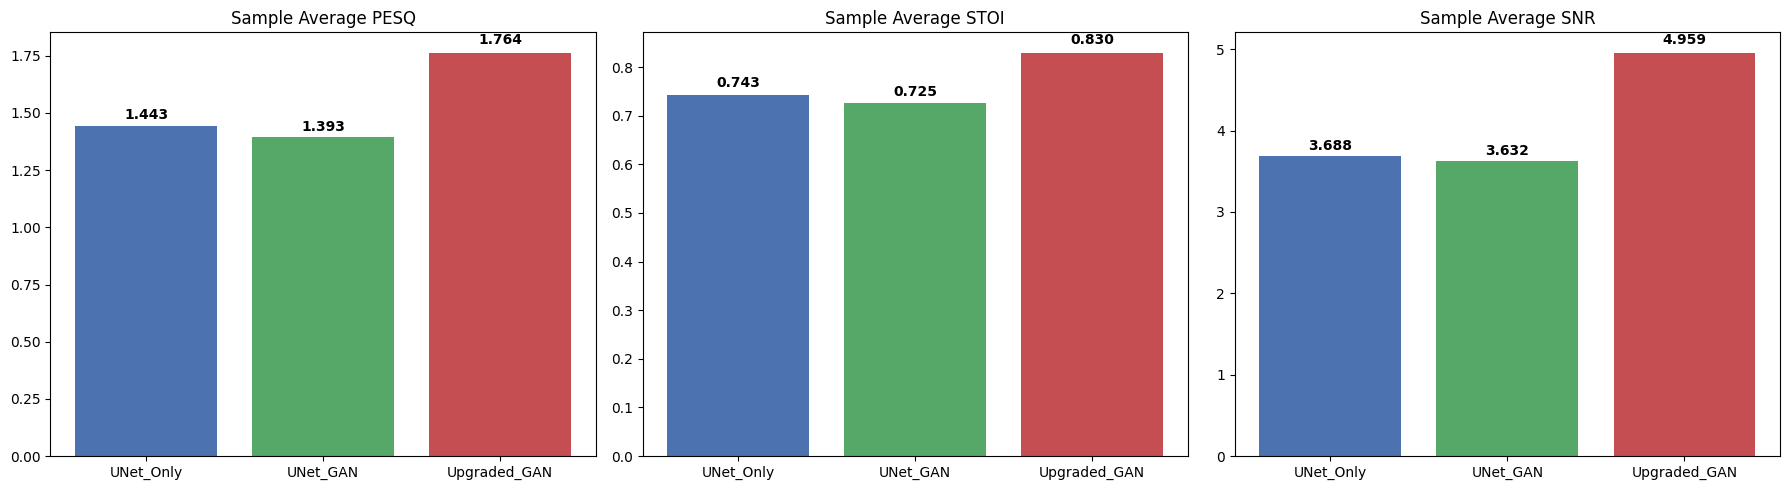

In [8]:
!pip install -q pesq pystoi

import os
import random
import zipfile
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import math
from pesq import pesq
from pystoi import stoi
from google.colab import drive

# 1. 구글 드라이브 마운트
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive', force_remount=True)

# 2. 경로 설정 (Validation 전용 데이터셋으로 변경)
DATA_DIR = '/content/drive/MyDrive/UNet'
COMPARATION_DIR = '/content/drive/MyDrive/UNet_GAN_Upgraded/Comparation'
RESULT_DIR = f'{COMPARATION_DIR}/Validation_Results'

if not os.path.exists(RESULT_DIR):
    os.makedirs(RESULT_DIR)

# Validation용 압축 파일 경로
VOICE_VAL_ZIP = f'{DATA_DIR}/Korean_Voice/KsponSpeech_eval.zip'
NOISE_VAL_ZIP = f'{DATA_DIR}/Clean_Noise_Zips/Cleaned_Noise_All_Val.zip'

# 3. 모델 구조 정의
class UNetMasker(nn.Module):
    def __init__(self):
        super(UNetMasker, self).__init__()
        self.enc1 = nn.Conv2d(1, 32, 3, padding=1)
        self.enc2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec2 = nn.Conv2d(64, 32, 3, padding=1)
        self.dec1 = nn.Conv2d(32, 1, 3, padding=1)
    def forward(self, x):
        e1 = F.relu(self.enc1(x))
        e2 = F.relu(self.enc2(self.pool(e1)))
        d2 = F.relu(self.dec2(self.up(e2)))
        if d2.size() != e1.size(): d2 = F.interpolate(d2, size=e1.shape[2:])
        mask = torch.sigmoid(self.dec1(d2))
        return x * mask, mask

class ResBlock(nn.Module):
    def __init__(self, channels):
        super(ResBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels)
        )
    def forward(self, x):
        return F.leaky_relu(x + self.conv(x), 0.2)

class UpgradedUNet(nn.Module):
    def __init__(self):
        super(UpgradedUNet, self).__init__()
        self.enc1 = nn.Sequential(nn.Conv2d(1, 64, 3, padding=1), nn.LeakyReLU(0.2))
        self.res1 = ResBlock(64)
        self.down1 = nn.Conv2d(64, 128, 4, stride=2, padding=1)
        self.res2 = ResBlock(128)
        self.down2 = nn.Conv2d(128, 256, 4, stride=2, padding=1)
        self.res3 = ResBlock(256)
        self.up2 = nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1)
        self.dec2 = nn.Sequential(nn.Conv2d(256, 128, 3, padding=1), ResBlock(128))
        self.up1 = nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1)
        self.dec1 = nn.Sequential(nn.Conv2d(128, 64, 3, padding=1), ResBlock(64))
        self.final = nn.Conv2d(64, 1, 3, padding=1)
    def forward(self, x):
        e1 = self.res1(self.enc1(x))
        e2 = self.res2(F.leaky_relu(self.down1(e1), 0.2))
        e3 = self.res3(F.leaky_relu(self.down2(e2), 0.2))
        d2 = self.up2(e3)
        if d2.size() != e2.size(): d2 = F.interpolate(d2, size=e2.shape[2:])
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        if d1.size() != e1.size(): d1 = F.interpolate(d1, size=e1.shape[2:])
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        mask = torch.sigmoid(self.final(d1))
        return x * mask, mask

# 4. 헬퍼 함수
def get_spec(audio):
    window = torch.hann_window(512).to(audio.device)
    spec = torch.stft(audio.squeeze(1), n_fft=512, hop_length=160, window=window, return_complex=True, center=True)
    return torch.abs(spec), torch.angle(spec)

def spec_to_wav(mag, phase):
    complex_spec = torch.polar(mag, phase)
    return torch.istft(complex_spec, n_fft=512, hop_length=160, center=True)

def get_validation_samples(voice_zip, noise_zip, temp_dir='/content/temp_val'):
    if not os.path.exists(temp_dir): os.makedirs(temp_dir)

    # 음성: eval_clean 또는 eval_other에서 무작위 선택
    with zipfile.ZipFile(voice_zip, 'r') as z:
        valid_infos = [info for info in z.infolist() if (('eval_clean' in info.filename) or ('eval_other' in info.filename)) and info.filename.endswith('.pcm')]
        target_info = random.choice(valid_infos)
        z.extract(target_info, temp_dir)
        voice_path = os.path.join(temp_dir, target_info.filename)

    # 소음: Val 전용 소음 압축파일에서 선택
    with zipfile.ZipFile(noise_zip, 'r') as z:
        wav_files = [f for f in z.namelist() if f.endswith('.wav')]
        target_wav = random.choice(wav_files)
        z.extract(target_wav, temp_dir)
        noise_path = os.path.join(temp_dir, target_wav)

    return voice_path, noise_path

def calculate_metrics(clean_wav, denoised_wav, sr=16000):
    min_len = min(len(clean_wav), len(denoised_wav))
    clean_wav = clean_wav[:min_len]
    denoised_wav = denoised_wav[:min_len]
    try:
        pesq_score = pesq(sr, clean_wav, denoised_wav, 'wb')
    except:
        pesq_score = 1.0 # 실패 시 최소값
    stoi_score = stoi(clean_wav, denoised_wav, sr, extended=False)
    noise = clean_wav - denoised_wav
    snr_score = 10 * math.log10(np.sum(clean_wav**2) / (np.sum(noise**2) + 1e-9))
    return pesq_score, stoi_score, snr_score

# 5. 모델 로드
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_info = {
    'UNet_Only': {'path': f'{COMPARATION_DIR}/unet_only_model.pth', 'class': UNetMasker},
    'UNet_GAN': {'path': f'{COMPARATION_DIR}/unet_gan_model.pth', 'class': UNetMasker},
    'Upgraded_GAN': {'path': f'{COMPARATION_DIR}/upgraded_gan_model.pth', 'class': UpgradedUNet}
}

models = {}
for name, info in model_info.items():
    if os.path.exists(info['path']):
        m = info['class']().to(device)
        checkpoint = torch.load(info['path'], map_location=device)
        m.load_state_dict(checkpoint['generator_state_dict'] if 'generator_state_dict' in checkpoint else (checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint))
        m.eval()
        models[name] = m
        print(f"✅ 모델 로드 완료: {name}")

# 6. 전체 Validation 데이터셋 중 200개 무작위 샘플 검증 수행
import random

metrics_history = {name: {'PESQ': [], 'STOI': [], 'SNR': []} for name in models.keys()}

temp_dir = '/content/temp_val_limited'
if not os.path.exists(temp_dir): os.makedirs(temp_dir)

# 4초 기준 바이트 (16kHz, 16bit mono)
MIN_BYTES = 128000
# 검증할 샘플 수 제한
LIMIT_SAMPLES = 200

print(f"\n🚀 전체 {total_files if 'total_files' in locals() else '조건 만족'}개 데이터 중 {LIMIT_SAMPLES}개를 무작위 추출하여 검증을 시작합니다...")

with zipfile.ZipFile(VOICE_VAL_ZIP, 'r') as v_zip, zipfile.ZipFile(NOISE_VAL_ZIP, 'r') as n_zip:
    # 1. 조건을 만족하는 모든 파일 목록 확보
    all_eligible_files = [
        info for info in v_zip.infolist()
        if (('eval_clean' in info.filename) or ('eval_other' in info.filename))
        and info.filename.endswith('.pcm')
        and info.file_size >= MIN_BYTES
    ]

    # 2. 200개 무작위 샘플링 (전체 개수가 200개보다 적으면 전체 사용)
    num_to_sample = min(len(all_eligible_files), LIMIT_SAMPLES)
    selected_voice_files = random.sample(all_eligible_files, num_to_sample)

    all_noise_files = [f for f in n_zip.namelist() if f.endswith('.wav')]

    print(f"📦 선별된 {num_to_sample}개의 샘플에 대해 평가를 진행합니다.")

    for i, v_info in enumerate(selected_voice_files):
        # 파일 추출
        v_zip.extract(v_info, temp_dir)
        v_path = os.path.join(temp_dir, v_info.filename)

        n_name = random.choice(all_noise_files)
        n_zip.extract(n_name, temp_dir)
        n_path = os.path.join(temp_dir, n_name)

        # 음성 데이터 로드 (2바이트 정렬 보정)
        with open(v_path, 'rb') as f:
            raw_data = f.read()
            valid_len = (len(raw_data) // 2) * 2
            clean = np.frombuffer(raw_data[:valid_len], dtype=np.int16).astype(np.float32) / 32768.0

        # 소음 데이터 로드
        noise, _ = librosa.load(n_path, sr=16000)

        # 4초(64000 샘플) 정렬
        sample_len = 64000
        clean = clean[:sample_len]
        if len(noise) < sample_len:
            noise = np.tile(noise, int(np.ceil(sample_len / len(noise))))[:sample_len]
        else:
            noise = noise[:sample_len]

        noisy = clean + noise * 0.5

        # 모델 추론
        with torch.no_grad():
            noisy_t = torch.FloatTensor(noisy).unsqueeze(0).unsqueeze(0).to(device)
            mag, phase = get_spec(noisy_t)
            mag = mag.unsqueeze(1)

            for name, model in models.items():
                denoised_mag, _ = model(mag)
                denoised_wav = spec_to_wav(denoised_mag.squeeze(1).cpu(), phase.cpu())

                p, s, snr = calculate_metrics(clean, denoised_wav[0].numpy())
                metrics_history[name]['PESQ'].append(p)
                metrics_history[name]['STOI'].append(s)
                metrics_history[name]['SNR'].append(snr)

        # 진행 상황 표시 (10개 단위)
        if (i + 1) % 10 == 0:
            print(f"⏳ 진행 중: {i + 1}/{num_to_sample} 완료...")

        # 즉시 삭제하여 용량 확보
        os.remove(v_path)
        os.remove(n_path)

# 7. 최종 결과 출력 및 평균 그래프 생성
print("\n" + "="*60)
print(f"📊 Validation 결과 (무작위 {num_to_sample}개 샘플 평균)")
print("="*60)

avg_metrics = {name: {m: np.mean(vals) for m, vals in metrics.items()} for name, metrics in metrics_history.items()}

for name, m in avg_metrics.items():
    print(f"[{name:12}] PESQ: {m['PESQ']:.4f} | STOI: {m['STOI']:.4f} | SNR: {m['SNR']:.4f}dB")

# 그래프 생성
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#4C72B0', '#55A868', '#C44E52']
for idx, metric in enumerate(['PESQ', 'STOI', 'SNR']):
    values = [avg_metrics[name][metric] for name in models.keys()]
    axes[idx].bar(models.keys(), values, color=colors)
    axes[idx].set_title(f'Sample Average {metric}')
    for i, v in enumerate(values):
        axes[idx].text(i, v + (v * 0.02), f"{v:.3f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'sampled_val_metrics.png'))
plt.show()